# Load trained Hist-CNN (trial_0140)

Loads the checkpoint at
`results/hist_cnn_NOTS_output_3_4_26/trial_0140_learning_rate=5.0e-04_history=1_kernel_sizes=3_conv_channels=256_fc_dims=256_seed0/`

Model hyperparameters come from the trial's `config.yaml`; the only things not in the config
(`n_stim_channels`, `n_neurons`) are inferred from the checkpoint's state_dict.

In [80]:
from pathlib import Path
import yaml
import torch
import cvxpy as cp
import numpy as np


import sys
sys.path.insert(0, str(Path.cwd()))
from models import SimpleCausalSpikeCNN

TRIAL_DIR = Path('results/hist_cnn_NOTS_output_3_4_26/trial_0140_learning_rate=5.0e-04_history=1_kernel_sizes=3_conv_channels=256_fc_dims=256_seed0')
CKPT_PATH = TRIAL_DIR / 'best_stim_spike_model.pt'
CONFIG_PATH = TRIAL_DIR / 'config.yaml'

with open(CONFIG_PATH) as f:
    cfg = yaml.safe_load(f)
cfg

{'artifact_path': None,
 'batch_size': 16,
 'conv_channels': [256],
 'criterion_fn': 'poisson',
 'datadir': '/scratch/sb272/patterns5k_data/oracle_ICMS_150/',
 'dropout': 0.2,
 'embedding_dim': 0,
 'encoding_mode': 'current',
 'fc_dims': [256],
 'history': 1,
 'inference_mode': False,
 'init_bias': None,
 'init_state': True,
 'input_bin_size_ms': 10,
 'kernel_sizes': [3],
 'learning_rate': 0.0005,
 'max_time_ms': 600,
 'model_type': 'cnn',
 'n_input_bins': 60,
 'n_output_bins': 60,
 'num_epochs': 50,
 'output_bin_size_ms': 10,
 'output_offset': 0,
 'patience': 10,
 'pattern_limit': 50,
 'pooling': 'none',
 'problematic_neurons': [19, 104, 201, 211, 300, 310, 311, 312],
 'seed': 0,
 'skip_oracle_plots': True,
 'split_mode': 'oracle',
 'sum_loss': False,
 'weight_decay': 0.0001,
 'weight_loss': 1}

In [2]:
# ---- Binning / timing (make these obvious) ----
INPUT_BIN_SIZE_MS  = cfg['input_bin_size_ms']   # 10 ms per input bin
OUTPUT_BIN_SIZE_MS = cfg['output_bin_size_ms']  # 10 ms per output bin
N_INPUT_BINS       = cfg['n_input_bins']        # 60 -> 600 ms window
N_OUTPUT_BINS      = cfg['n_output_bins']       # 60 -> 600 ms window
MAX_TIME_MS        = cfg['max_time_ms']         # 600 ms
OUTPUT_OFFSET      = cfg['output_offset']       # 0 bins

# ---- Model hyperparameters ----
MODEL_TYPE     = cfg['model_type']              # 'cnn'  (SimpleCausalSpikeCNN)
ENCODING_MODE  = cfg['encoding_mode']           # 'current'
HISTORY        = cfg['history']                 # 1 -> spike history channels concatenated to stim
CONV_CHANNELS  = cfg['conv_channels']           # [256]
KERNEL_SIZES   = cfg['kernel_sizes']            # [3]
FC_DIMS        = cfg['fc_dims']                 # [256]
DROPOUT        = cfg['dropout']                 # 0.2
EMBEDDING_DIM  = cfg['embedding_dim']           # 0 (Identity)
INIT_STATE     = cfg['init_state']              # True -> valid conv

print(f'Bin size: input={INPUT_BIN_SIZE_MS} ms, output={OUTPUT_BIN_SIZE_MS} ms')
print(f'Window : {N_INPUT_BINS} input bins × {INPUT_BIN_SIZE_MS} ms = {N_INPUT_BINS * INPUT_BIN_SIZE_MS} ms')
print(f'         {N_OUTPUT_BINS} output bins × {OUTPUT_BIN_SIZE_MS} ms = {N_OUTPUT_BINS * OUTPUT_BIN_SIZE_MS} ms')
print(f'Model  : {MODEL_TYPE}  history={HISTORY}  encoding={ENCODING_MODE}')
print(f'         conv_channels={CONV_CHANNELS}  kernel_sizes={KERNEL_SIZES}  fc_dims={FC_DIMS}')

Bin size: input=10 ms, output=10 ms
Window : 60 input bins × 10 ms = 600 ms
         60 output bins × 10 ms = 600 ms
Model  : cnn  history=1  encoding=current
         conv_channels=[256]  kernel_sizes=[3]  fc_dims=[256]


In [3]:
# ---- Infer n_stim_channels / n_neurons from the checkpoint ----
# run_experiment.py: for MODEL_TYPE='cnn' with ENCODING_MODE='current' and HISTORY>=1:
#   n_model_input_channels = n_stim_channels + n_neurons
# The first conv layer's in_channels therefore equals (n_stim_channels + n_neurons).
# The final FC layer's out_features equals n_neurons.
state = torch.load(CKPT_PATH, map_location='cpu', weights_only=True)

# First conv weight: shape (out_ch, in_ch, k)
first_conv_w = next(v for k, v in state.items() if k.startswith('conv_stack') and k.endswith('.weight') and v.ndim == 3)
first_conv_in_ch = first_conv_w.shape[1]

# Last FC weight: shape (n_neurons, prev)
fc_weight_keys = sorted(k for k in state if k.startswith('fc.') and k.endswith('.weight'))
n_neurons = state[fc_weight_keys[-1]].shape[0]

uses_history = ENCODING_MODE == 'current' and HISTORY is not None and HISTORY > 0
n_stim_channels = first_conv_in_ch - n_neurons if uses_history else first_conv_in_ch

print(f'Inferred n_stim_channels = {n_stim_channels}')
print(f'Inferred n_neurons      = {n_neurons}')
print(f'First conv in_channels  = {first_conv_in_ch}  (= n_stim_channels + n_neurons if history else n_stim_channels)')

Inferred n_stim_channels = 42
Inferred n_neurons      = 63
First conv in_channels  = 105  (= n_stim_channels + n_neurons if history else n_stim_channels)


In [4]:
# ---- Build model and load weights ----
n_model_input_channels = n_stim_channels + n_neurons if uses_history else n_stim_channels
model = SimpleCausalSpikeCNN(
    n_stim_channels=n_model_input_channels,
    n_neurons=n_neurons,
    n_input_bins=N_INPUT_BINS,
    n_output_bins=N_OUTPUT_BINS,
    embedding_dim=EMBEDDING_DIM,
    conv_channels=CONV_CHANNELS,
    kernel_sizes=KERNEL_SIZES,
    fc_dims=FC_DIMS,
    dropout=DROPOUT,
    use_init_state=INIT_STATE,
)

missing, unexpected = model.load_state_dict(state, strict=False)
print(f'Missing keys   : {missing}')
print(f'Unexpected keys: {unexpected}')
model.eval()
n_params = sum(p.numel() for p in model.parameters())
print(f'Loaded model: {n_params:,} params')

Missing keys   : []
Unexpected keys: []
Loaded model: 163,391 params


In [81]:
import plotly.graph_objects as go
from sklearn.decomposition import PCA

class SystemMouse():
    def __init__(self, n_neurons, radius, mean_rate, seed=0):
        super().__init__()
        self.n_neurons = n_neurons
        self.rng = np.random.default_rng(seed)
        self.phi      = self.rng.uniform(0, 2*np.pi, size=n_neurons)           # preferred direction

        self.radius = radius
        self.mean_rate = mean_rate


        directions = np.array([0, 45, 90, 135, 180, 225, 270, 315])  # degrees

        self.theta = np.deg2rad(directions)                           # (8,)
        self.phi      = self.rng.uniform(0, 2*np.pi, size=self.n_neurons)           # preferred orientation of each neuron
        self.phi_bases = [np.cos(self.phi) / np.sqrt(self.n_neurons / 2), np.sin(self.phi) / np.sqrt(self.n_neurons / 2)]  # normalize so that the population response has a reasonable radius
        self.avg_vectors = self.mean_rate + self.radius * (np.cos(self.theta[:, None]) * self.phi_bases[0] + np.sin(self.theta[:, None]) * self.phi_bases[1])
        self.pca = PCA(n_components=2)
        self.pca.fit(self.avg_vectors)
        self.proj , _ = np.linalg.qr(np.array([self.avg_vectors.mean(0), self.pca.components_[0], self.pca.components_[1]]).T)  # Get the orthonormal basis from QR decomposition
        self.avg_proj = self.avg_vectors @ self.proj  # shape: (8, 3)

    def generate_response(self, stimulus_direction_rad):
        # Compute the response of each neuron to the stimulus direction
        stimulus_vector = np.array([np.cos(stimulus_direction_rad), np.sin(stimulus_direction_rad)])  # shape: (2,)
        tuning_response = self.bases @ stimulus_vector  # shape: (8,)

        # Add baseline firing rate and noise
        firing_rates = self.mean_rate + tuning_response  # shape: (8,)
        firing_rates = np.clip(firing_rates, a_min=0, a_max=None)  # Ensure non-negative firing rates
        return firing_rates

    def plot_avg_proj(self, n_ring=256):
        # Dense evaluation of the underlying parametric ring, projected the same way
        theta_dense = np.linspace(0, 2*np.pi, n_ring, endpoint=True)
        ring_vecs = self.mean_rate + self.radius * (
            np.cos(theta_dense[:, None]) * self.phi_bases[0]
            + np.sin(theta_dense[:, None]) * self.phi_bases[1]
        )
        ring_proj = ring_vecs @ self.proj  # (n_ring, 3)

        fig = go.Figure()
        fig.add_trace(go.Scatter3d(
            x=ring_proj[:, 0], y=ring_proj[:, 1], z=ring_proj[:, 2],
            mode='lines',
            line=dict(color=theta_dense, colorscale='HSV', width=6),
            showlegend=False,
            hoverinfo='skip',
        ))
        fig.add_trace(go.Scatter3d(
            x=self.avg_proj[:, 0], y=self.avg_proj[:, 1], z=self.avg_proj[:, 2],
            mode='markers+text',
            marker=dict(
                size=8,
                color=self.theta,
                colorscale='HSV',
                cmin=0, cmax=2*np.pi,
                colorbar=dict(title='Stimulus Direction (radians)'),
                line=dict(color='black', width=1),
                showscale=True,
            ),
            text=[f'{int(np.rad2deg(t))}°' for t in self.theta],
            textposition='top center',
            showlegend=False,
        ))
        fig.update_layout(
            title='Average Neural Response Projected onto PCA Components',
            scene=dict(
                xaxis_title='CIS', yaxis_title='PC1', zaxis_title='PC2',
                aspectmode='data',
                camera=dict(eye=dict(x=0.1, y=0.1, z=2.2)),  # top-down on the ring plane
            ),
            width=800, height=700,
        )
        return fig
class NNLS_Controller:
    '''
    Controller that uses non-negative least squares to 
    compute combination of patterns to elicit a targeted number of spikes per neuron. 
    '''
    def __init__(self):
        pass

    def compute_stimulus(self, sta_matx, target_response):
        '''
        sta_matx: (n_neurons, n_patterns)  - each column is the response of all neurons to a single pattern
        target_response: (n_neurons,) - desired response for each neuron
        returns: (n_patterns, error) - non-negative weights for each pattern, and the resulting error norm
        '''
        n_patterns = sta_matx.shape[1]
        x = cp.Variable(n_patterns, nonneg=True)
        objective = cp.Minimize(cp.sum_squares((sta_matx @ x - target_response)))
        problem = cp.Problem(objective)
        problem.solve(solver=cp.OSQP, verbose=False)    
        if problem.status not in ["optimal", "optimal_inaccurate"]:
            raise ValueError(f"Optimization failed with status: {problem.status}")
        return x.value, np.linalg.norm(sta_matx @ x.value - target_response)


In [77]:
# ---- Load raw data + build per-pattern binned stim tensors matching training ----
# Uses the same cfg the model was trained with so binning / encoding is identical.
# BinnedStimSpikeDataset._encode_pattern_binned handles the 10 ms "current" encoding
# (including the alternating +/-3 current values used by HistCNN).

from utils import load_raw_data, BinnedStimSpikeDataset

raw = load_raw_data(cfg)
pattern_df        = raw['pattern_df']
spike_responses   = raw['spike_responses']
channel_to_index  = raw['channel_to_index']
timing_to_pattern = raw['timing_to_pattern']
unique_trials     = raw['unique_trials']
spiking_neurons   = raw['spiking_neurons']

# Build a dataset purely to reuse its pattern-binning logic. We pass all trials
# so every unique pattern gets encoded. trial_indices is only used to decide
# which (trial, t) samples to enumerate — doesn't affect pattern_stims.
_ds = BinnedStimSpikeDataset(
    pattern_df=pattern_df,
    spike_responses=spike_responses,
    channel_to_index=channel_to_index,
    timing_to_pattern=timing_to_pattern,
    trial_indices=list(spike_responses.keys()),
    encoding_mode=ENCODING_MODE,
    input_bin_size_ms=INPUT_BIN_SIZE_MS,
    output_bin_size_ms=OUTPUT_BIN_SIZE_MS,
    n_input_bins=N_INPUT_BINS,
    n_output_bins=N_OUTPUT_BINS,
    max_time_ms=MAX_TIME_MS,
    output_offset=OUTPUT_OFFSET,
    init_state=INIT_STATE,
    n_initial_state_bins=sum(k - 1 for k in KERNEL_SIZES) if INIT_STATE else 0,
    history=HISTORY,
)

# pattern_stims: dict[pattern_name] -> (n_stim_channels, n_input_bins) int64
# Stack into one tensor aligned with a list of names, so downstream code can
# batch-forward them through the model.
pattern_names = sorted(_ds.pattern_stims.keys())
pattern_stim_tensor = torch.tensor(
    np.stack([_ds.pattern_stims[n] for n in pattern_names], axis=0),
    dtype=torch.float32,
)  # (n_patterns, n_stim_channels, n_input_bins)

print(f'n_patterns        : {len(pattern_names)}')
print(f'pattern_stim_tensor shape: {tuple(pattern_stim_tensor.shape)}  '
      f'(expected: (N, {n_stim_channels}, {N_INPUT_BINS}))')
print(f'unique stim values in encoding "{ENCODING_MODE}": '
      f'{torch.unique(pattern_stim_tensor).tolist()}')

Datadir '/scratch/sb272/patterns5k_data/oracle_ICMS_150/' not found; falling back to 'data/oracle_ICMS_150/'
Loading data …
63 unique neurons after dropping problematic neurons
Stimulation channels: 42, Spiking neurons: 63
Unique patterns: 4050, Total trials: 5000
1 trials were added in spike responses for initial state that were not in the specified trial_indices
n_patterns        : 4050
pattern_stim_tensor shape: (4050, 42, 60)  (expected: (N, 42, 60))
unique stim values in encoding "current": [-3.0, 0.0, 3.0]


In [61]:
# ---- Per-column STA accumulation ----
# For every (trial, t) where t is a 10ms bin, the model predicts a 63-dim rate
# vector y_hat[:, t]. We key on the stim column pattern_stims[pattern][:, t]
# (a 42-tuple over channels), accumulate sum(y_hat[:, t]) and count(t), then
# divide to get sta[column] ∈ R^n_neurons.
#
# History channels during the forward pass are ground-truth spike history from
# the trial (via BinnedStimSpikeDataset with init_state=True, history=1), which
# matches how the model was trained in teacher-forcing mode.

from torch.utils.data import DataLoader, ConcatDataset
from sklearn.model_selection import train_test_split
from collections import defaultdict

SEED = cfg['seed']
SPLIT_MODE = cfg.get('split_mode', 'oracle')

# Reproduce the exact train/val split used by run_experiment.py
all_timing_indices = list(spike_responses.keys())
unique_trials_info = pattern_df[['pattern_timing_index', 'pattern_name', 'is_oracle']].drop_duplicates()
if SPLIT_MODE == 'oracle':
    oracle_timing = unique_trials_info[unique_trials_info['is_oracle']]['pattern_timing_index'].tolist()
    sample_timing = unique_trials_info[~unique_trials_info['is_oracle']]['pattern_timing_index'].tolist()
    train_indices, val_indices = train_test_split(sample_timing, test_size=0.15, random_state=SEED)
else:
    train_val, _ = train_test_split(all_timing_indices, test_size=0.15, random_state=SEED)
    train_indices, val_indices = train_test_split(train_val, test_size=0.176, random_state=SEED)

print(f'train={len(train_indices)}  val={len(val_indices)}  (combined for STA accumulation)')

N_INIT_STATE_BINS = sum(k - 1 for k in KERNEL_SIZES) if INIT_STATE else 0

dataset_kwargs = dict(
    pattern_df=pattern_df,
    spike_responses=spike_responses,
    channel_to_index=channel_to_index,
    timing_to_pattern=timing_to_pattern,
    encoding_mode=ENCODING_MODE,
    input_bin_size_ms=INPUT_BIN_SIZE_MS,
    output_bin_size_ms=OUTPUT_BIN_SIZE_MS,
    n_input_bins=N_INPUT_BINS,
    n_output_bins=N_OUTPUT_BINS,
    max_time_ms=MAX_TIME_MS,
    output_offset=OUTPUT_OFFSET,
    init_state=INIT_STATE,
    n_initial_state_bins=N_INIT_STATE_BINS,
    history=HISTORY,
)
train_ds = BinnedStimSpikeDataset(trial_indices=train_indices, **dataset_kwargs)
val_ds   = BinnedStimSpikeDataset(trial_indices=val_indices,   **dataset_kwargs)

# With n_input_bins == total_bins (60) and output_offset=0, each trial yields
# exactly one sample at t=0, so DataLoader order == trial order in .samples.
assert all(t == 0 for _, t in train_ds.samples)
assert all(t == 0 for _, t in val_ds.samples)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device).eval()

col_sum   = defaultdict(lambda: np.zeros(n_neurons, dtype=np.float64))
col_count = defaultdict(int)

@torch.no_grad()
def accumulate(ds):
    loader = DataLoader(ds, batch_size=64, shuffle=False, num_workers=0)
    sample_idx = 0
    for x, _ in loader:
        x = x.to(device)
        # Model output: (B, n_neurons, n_output_bins=60). Criterion was poisson
        # (log-link), so convert to rates with exp() to stay on a meaningful scale.
        y_hat = model(x).exp().cpu().numpy()  # (B, n_neurons, 60)
        B = y_hat.shape[0]
        for b in range(B):
            timing_idx, _t0 = ds.samples[sample_idx + b]
            stim = ds.pattern_stims[ds.timing_to_pattern[timing_idx]]  # (42, 60)
            for t in range(N_OUTPUT_BINS):
                key = tuple(stim[:, t].tolist())
                col_sum[key]   += y_hat[b, :, t]
                col_count[key] += 1
        sample_idx += B

accumulate(train_ds)
accumulate(val_ds)

# Materialize into aligned arrays
columns = np.array(list(col_sum.keys()), dtype=np.int64)           # (K, n_stim_channels)
counts  = np.array([col_count[tuple(c)] for c in columns], dtype=np.int64)  # (K,)
sta_matx_cols = np.stack(
    [col_sum[tuple(c)] / col_count[tuple(c)] for c in columns], axis=1
).astype(np.float32)                                               # (n_neurons, K)

print(f'unique stim columns : {len(columns)}')
print(f'total bin samples   : {counts.sum()} '
      f'(expected {(len(train_ds) + len(val_ds)) * N_OUTPUT_BINS})')
print(f'sta_matx_cols shape : {sta_matx_cols.shape}')
print(f'count histogram     : min={counts.min()}  median={int(np.median(counts))}  max={counts.max()}')

train=3400  val=600  (combined for STA accumulation)
1099 trials were added in spike responses for initial state that were not in the specified trial_indices
536 trials were added in spike responses for initial state that were not in the specified trial_indices
unique stim columns : 12082
total bin samples   : 240000 (expected 240000)
sta_matx_cols shape : (63, 12082)
count histogram     : min=3  median=3  max=128568


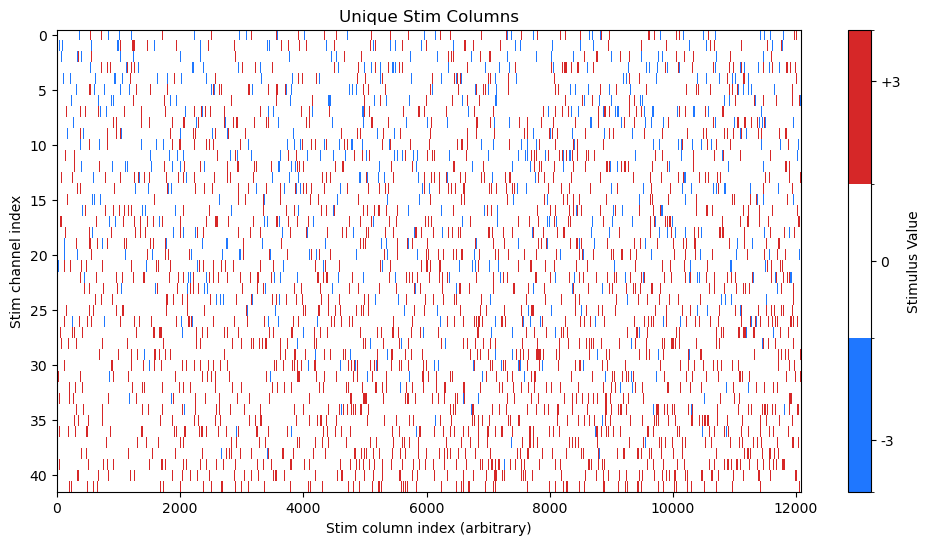

In [66]:
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm

# Discrete colormap: -3 -> blue, 0 -> white, +3 -> red
cmap = ListedColormap(['#1f77ff', 'white', '#d62728'])
norm = BoundaryNorm([-4, -1, 1, 4], cmap.N)

plt.figure(figsize=(12, 6))
im = plt.imshow(columns.T, aspect='auto', cmap=cmap, norm=norm, interpolation='nearest')
plt.xlabel("Stim column index (arbitrary)")
plt.ylabel("Stim channel index")
plt.title("Unique Stim Columns")
cbar = plt.colorbar(im, ticks=[-3, 0, 3], label='Stimulus Value')
cbar.ax.set_yticklabels(['-3', '0', '+3'])
plt.show()

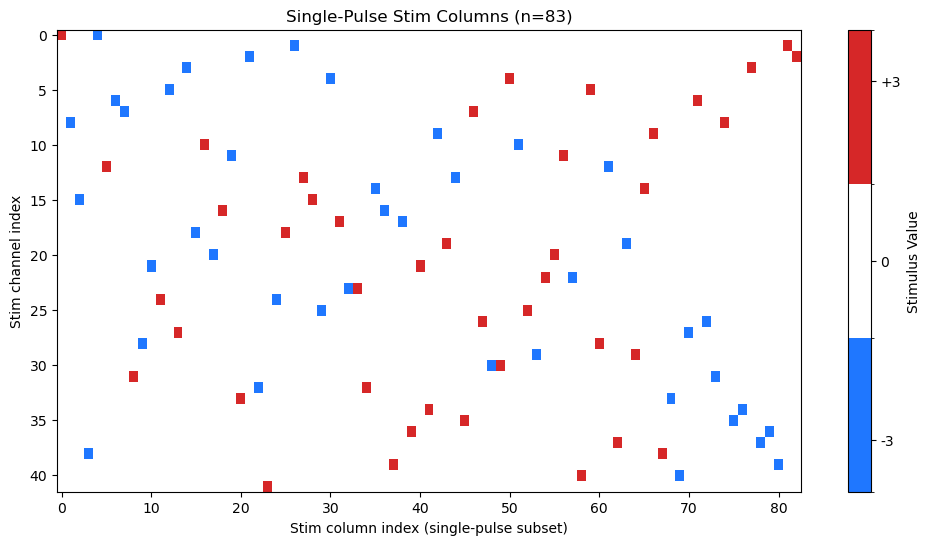

In [67]:
single_pulse_mask = np.count_nonzero(columns, axis=1) == 1
single_pulse_stims = columns[single_pulse_mask]

plt.figure(figsize=(12, 6))
im = plt.imshow(single_pulse_stims.T, aspect='auto', cmap=cmap, norm=norm, interpolation='nearest')
plt.xlabel("Stim column index (single-pulse subset)")
plt.ylabel("Stim channel index")
plt.title(f"Single-Pulse Stim Columns (n={len(single_pulse_stims)})")
cbar = plt.colorbar(im, ticks=[-3, 0, 3], label='Stimulus Value')
cbar.ax.set_yticklabels(['-3', '0', '+3'])
plt.show()

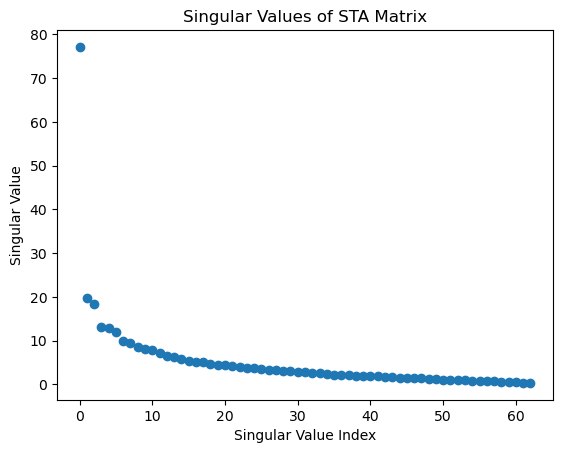

In [68]:
u, e, v_t = np.linalg.svd(sta_matx_cols)
plt.scatter(np.arange(len(e)), e)
plt.xlabel("Singular Value Index")
plt.ylabel("Singular Value")
plt.title("Singular Values of STA Matrix")
plt.show()

direction         : 180°
#active weights   : 10 / 83
residual ‖·‖₂     : 34.1848
target mean rate  : 9.980
achieved mean rate: 8.121


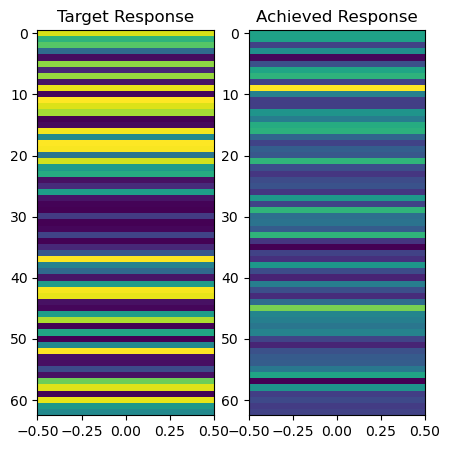

In [82]:
# The SystemMouse is a simple model of how the mouse's neurons
# respond to different stimulus patterns.
# The SpikeCNN predicts a per-stim-column STA (sta_matx_cols: n_neurons × K).
# The NNLS_Controller finds non-negative weights over the K columns whose
# STA-weighted sum matches a targeted per-neuron response.

n_electrodes = 32
radius = 1.0
mean_firing = 10.0

mouse = SystemMouse(n_neurons=n_neurons, radius=radius, mean_rate=mean_firing)

# Restrict the pattern dictionary to single-pulse stim columns.
sta_single_pulse = sta_matx_cols[:, single_pulse_mask]  # (n_neurons, n_single_pulse)

# Pick one of the 8 stimulus directions (0..7). avg_vectors[i] is the
# target firing-rate vector over all n_neurons for direction theta[i].
direction_idx = 4                        # e.g. 180°
target_response = mouse.avg_vectors[direction_idx]   # (n_neurons,)

controller = NNLS_Controller()
weights, error = controller.compute_stimulus(sta_single_pulse, target_response)

print(f'direction         : {np.rad2deg(mouse.theta[direction_idx]):.0f}°')
print(f'#active weights   : {(weights > 1e-8).sum()} / {weights.size}')
print(f'residual ‖·‖₂     : {error:.4f}')
print(f'target mean rate  : {target_response.mean():.3f}')
print(f'achieved mean rate: {(sta_single_pulse @ weights).mean():.3f}')

f, ax = plt.subplots(1, 2, figsize=(5, 5))
ax[0].imshow(target_response[:, None], aspect='auto', cmap='viridis')
ax[0].set_title('Target Response')
ax[1].imshow((sta_single_pulse @ weights)[:, None], aspect='auto', cmap='viridis')
ax[1].set_title('Achieved Response')
plt.show()

In [85]:
approx = []
for target_idx in [0, 1, 2, 3, 4, 5, 6, 7]:
    target_response = mouse.avg_vectors[target_idx]
    weights, error = controller.compute_stimulus(sta_single_pulse, target_response)
    print(f'direction         : {np.rad2deg(mouse.theta[target_idx]):.0f}°')
    print(f'#active weights   : {(weights > 1e-8).sum()} / {weights.size}')
    print(f'residual ‖·‖₂     : {error:.4f}')
    print(f'target mean rate  : {target_response.mean():.3f}')
    print(f'achieved mean rate: {(sta_single_pulse @ weights).mean():3f}')
    approx.append(sta_single_pulse @ weights @ mouse.proj)  # project the achieved response into the same PCA space for visualization

fig = mouse.plot_avg_proj()
fig.add_trace(go.Scatter3d(
    x=np.array(approx)[:, 0], y=np.array(approx)[:, 1], z=np.array(approx)[:, 2],
    mode='markers',
    marker=dict(
        size=6,
        color=mouse.theta,
        colorscale='HSV',
        cmin=0, cmax=2*np.pi,
        colorbar=dict(title='Stimulus Direction (radians)'),
        line=dict(color='black', width=1),
        showscale=True,
    ),
    text=[f'Approx {int(np.rad2deg(t))}°' for t in mouse.theta],
    textposition='bottom center',
    showlegend=False,
))
fig.update_layout(
    title='STA-NNLS Approximation of Target Responses in PCA Space',
    scene=dict(
        xaxis_title='CIS', yaxis_title='PC1', zaxis_title='PC2',
        aspectmode='data',
        # camera=dict(eye=dict(x=0.1, y=0.1, z=2.2)),  # top-down on the ring plane
    ),
)  

fig.show()


    

direction         : 0°
#active weights   : 8 / 83
residual ‖·‖₂     : 34.3681
target mean rate  : 10.020
achieved mean rate: 8.152214
direction         : 45°
#active weights   : 10 / 83
residual ‖·‖₂     : 34.1565
target mean rate  : 10.000
achieved mean rate: 8.142747
direction         : 90°
#active weights   : 10 / 83
residual ‖·‖₂     : 34.0150
target mean rate  : 9.979
achieved mean rate: 8.129732
direction         : 135°
#active weights   : 11 / 83
residual ‖·‖₂     : 34.0290
target mean rate  : 9.971
achieved mean rate: 8.120790
direction         : 180°
#active weights   : 10 / 83
residual ‖·‖₂     : 34.1848
target mean rate  : 9.980
achieved mean rate: 8.121166
direction         : 225°
#active weights   : 10 / 83
residual ‖·‖₂     : 34.3892
target mean rate  : 10.000
achieved mean rate: 8.130634
direction         : 270°
#active weights   : 9 / 83
residual ‖·‖₂     : 34.5273
target mean rate  : 10.021
achieved mean rate: 8.143644
direction         : 315°
#active weights   : 8 / 8